In [33]:
# ===============================
# 1. Import Required Libraries
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv('h243.csv')




In [34]:
# ===============================
# 2. Data Cleaning
# ===============================

# Filter invalid MEPS codes
df = df[(df['REGION22'] > 0) & (df['AGE22X'] >= 0)]

# Recode MEPS missing codes to NaN
df['EDUCYR']   = df['EDUCYR'].where(df['EDUCYR'] >= 0, np.nan)
df['MARRY22X'] = df['MARRY22X'].where(df['MARRY22X'] >= 0, np.nan)

print("Cleaned dataset shape:", df.shape)
print("REGION22 values:", sorted(df['REGION22'].unique()))
print("AGE22X min:", df['AGE22X'].min())

Cleaned dataset shape: (22236, 1420)
REGION22 values: [1, 2, 3, 4]
AGE22X min: 0


In [35]:
# ===============================
# 3. Define Outcome & Predictors
# ===============================

import numpy as np

# -------------------------------
# 1. OUTCOME VARIABLE
# -------------------------------
# Total healthcare expenditure (MEPS 2022 usually = TOTEXP22)

df['high_exp'] = np.where(
    df['TOTEXP22'] > df['TOTEXP22'].median(),
    1,
    0
)

# -------------------------------
# 2. CREATE MULTIMORBIDITY
# -------------------------------

# Identify chronic condition variables available in your dataset
possible_dx = [col for col in df.columns if col.endswith('DX')]

print("Diagnosis variables found:")
print(possible_dx)

# Keep only common chronic conditions if they exist
chronic_vars = [col for col in possible_dx if col in [
    'DIABDX',    # Diabetes
    'HIBPDX',    # Hypertension
    'ASTHDX',    # Asthma
    'CHDDX',     # Coronary heart disease
    'STRKDX',    # Stroke
    'ARTHDX',    # Arthritis
    'CANCERDX'   # Cancer
]]

print("Chronic variables used:")
print(chronic_vars)

# Convert 2 (No) → 0
for col in chronic_vars:
    df[col] = df[col].replace({2: 0})

# Count number of chronic conditions
df['chronic_count'] = df[chronic_vars].sum(axis=1)

# Define multimorbidity (2+ chronic conditions)
df['multimorbidity'] = np.where(df['chronic_count'] >= 2, 1, 0)

# -------------------------------
# 3. DEFINE PREDICTORS
# -------------------------------

predictors = [
    'AGE22X',        # Age
    'SEX',           # Gender
    'RACEV1X',       # Race
    'REGION22',      # Region
    'POVCAT22',      # Poverty
    'INSCOV22',      # Insurance
    'EDUCYR',        # Education years
    'MARRY22X',      # Marital status
    'multimorbidity'
]

# Keep only existing columns (prevents KeyError)
predictors = [col for col in predictors if col in df.columns]

# Final modeling dataset
df_model = df[['high_exp'] + predictors].dropna()

print("\nFinal modeling variables:")
print(df_model.columns)

print("\nPreview:")
print(df_model.head())

Diagnosis variables found:
['HIBPDX', 'BPMLDX', 'CHDDX', 'ANGIDX', 'MIDX', 'OHRTDX', 'STRKDX', 'EMPHDX', 'CHOLDX', 'CANCERDX', 'ARTHDX', 'ASTHDX', 'ADHDADDX', 'HIEUIDX']
Chronic variables used:
['HIBPDX', 'CHDDX', 'STRKDX', 'CANCERDX', 'ARTHDX', 'ASTHDX']

Final modeling variables:
Index(['high_exp', 'AGE22X', 'SEX', 'RACEV1X', 'REGION22', 'POVCAT22',
       'INSCOV22', 'EDUCYR', 'MARRY22X', 'multimorbidity'],
      dtype='object')

Preview:
   high_exp  AGE22X  SEX  RACEV1X  REGION22  POVCAT22  INSCOV22  EDUCYR  \
0         1      77    2        2         2         3         2     6.0   
1         1      64    2        1         2         1         2    14.0   
2         1      67    1        1         2         4         2    17.0   
3         1      29    1        6         4         5         1    16.0   
4         1      51    2        1         1         4         1    16.0   

   MARRY22X  multimorbidity  
0       2.0               1  
1       3.0               1  
2       3.0  

In [36]:
# ===============================
# 4. Important Subgroups
# ===============================

# Gender Subgroups
male = df_model[df_model['SEX'] == 1]
female = df_model[df_model['SEX'] == 2]

# Region Subgroups (optional)
region_groups = df_model.groupby('REGION22')

# ===============================
# 5. Descriptive Statistics Tables
# ===============================

# ---- Table 1: Overall Summary ----
desc_table1 = df_model.describe()
print("\nDescriptive Statistics - Full Sample")
print(desc_table1)

# ---- Table 2: By Gender ----
desc_table2 = df_model.groupby('SEX').mean()
print("\nDescriptive Statistics - By Gender")
print(desc_table2)


Descriptive Statistics - Full Sample
           high_exp        AGE22X           SEX       RACEV1X      REGION22  \
count  20705.000000  20705.000000  20705.000000  20705.000000  20705.000000   
mean       0.518570     45.878580      1.531176      1.537117      2.741512   
std        0.499667     22.118888      0.499039      1.179539      1.006177   
min        0.000000      5.000000      1.000000      1.000000      1.000000   
25%        0.000000     28.000000      1.000000      1.000000      2.000000   
50%        1.000000     47.000000      2.000000      1.000000      3.000000   
75%        1.000000     65.000000      2.000000      2.000000      4.000000   
max        1.000000     85.000000      2.000000      6.000000      4.000000   

           POVCAT22      INSCOV22        EDUCYR      MARRY22X  multimorbidity  
count  20705.000000  20705.000000  20705.000000  20705.000000    20705.000000  
mean       3.667810      1.482492     12.069404      2.997827        0.260903  
std       

In [37]:
# ===============================
# Logistic Regression – FINAL FIX
# ===============================

import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# -------------------------------
# FULL SAMPLE MODEL
# -------------------------------

existing_predictors = [col for col in predictors if col in df_model.columns]

formula_full = "high_exp ~ " + " + ".join(existing_predictors)

model_full = smf.logit(formula=formula_full, data=df_model).fit()

print("\nFull Sample Results")
print(model_full.summary())

or_full = pd.DataFrame({
    "OR": np.exp(model_full.params),
    "CI Lower": np.exp(model_full.conf_int()[0]),
    "CI Upper": np.exp(model_full.conf_int()[1])
})

print("\nOdds Ratios – Full Sample")
print(or_full)


# -------------------------------
# SUBGROUP MODELS (REMOVE SEX)
# -------------------------------

# Remove SEX from subgroup models
subgroup_predictors = [col for col in existing_predictors if col != 'SEX']

formula_sub = "high_exp ~ " + " + ".join(subgroup_predictors)

# Male dataset
male = df_model[df_model['SEX'] == 1]

model_male = smf.logit(formula=formula_sub, data=male).fit()

or_male = pd.DataFrame({
    "OR": np.exp(model_male.params),
    "CI Lower": np.exp(model_male.conf_int()[0]),
    "CI Upper": np.exp(model_male.conf_int()[1])
})

print("\nOdds Ratios – Male")
print(or_male)


# Female dataset
female = df_model[df_model['SEX'] == 2]

model_female = smf.logit(formula=formula_sub, data=female).fit()

or_female = pd.DataFrame({
    "OR": np.exp(model_female.params),
    "CI Lower": np.exp(model_female.conf_int()[0]),
    "CI Upper": np.exp(model_female.conf_int()[1])
})

print("\nOdds Ratios – Female")
print(or_female)

Optimization terminated successfully.
         Current function value: 0.578242
         Iterations 6

Full Sample Results
                           Logit Regression Results                           
Dep. Variable:               high_exp   No. Observations:                20705
Model:                          Logit   Df Residuals:                    20695
Method:                           MLE   Df Model:                            9
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.1649
Time:                        22:02:56   Log-Likelihood:                -11972.
converged:                       True   LL-Null:                       -14337.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.7576      0.133    -13.177      0.000      -2.019      -1.

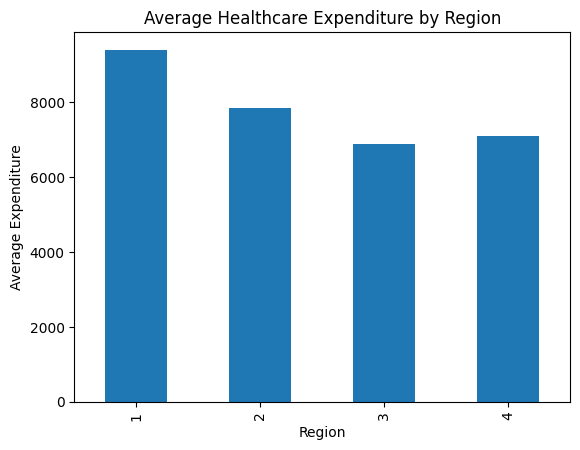

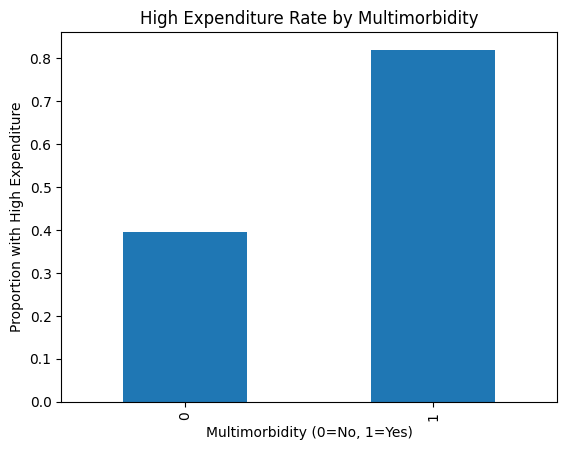

In [38]:

# ===============================
# 8. Descriptive Charts
# ===============================

# ---- Chart 1: Expenditure by Region ----
region_exp = df.groupby('REGION22')['TOTEXP22'].mean()

plt.figure()
region_exp.plot(kind='bar')
plt.title("Average Healthcare Expenditure by Region")
plt.xlabel("Region")
plt.ylabel("Average Expenditure")
plt.show()


# ---- Chart 2: High Expenditure Rate by Multimorbidity ----
multi_exp = df.groupby('multimorbidity')['high_exp'].mean()

plt.figure()
multi_exp.plot(kind='bar')
plt.title("High Expenditure Rate by Multimorbidity")
plt.xlabel("Multimorbidity (0=No, 1=Yes)")
plt.ylabel("Proportion with High Expenditure")
plt.show()



In [39]:
import numpy as np
import pandas as pd

df_fe = df.copy()

# ======================================================
# 1) OUTCOME ENGINEERING (continuous -> binary)
# ======================================================
# Option A: median split (what you did)
if "TOTEXP22" in df_fe.columns:
    df_fe["high_exp_median"] = (df_fe["TOTEXP22"] > df_fe["TOTEXP22"].median()).astype(int)

# Option B (recommended for rubric): top 10% spenders
if "TOTEXP22" in df_fe.columns:
    p90 = df_fe["TOTEXP22"].quantile(0.90)
    df_fe["high_exp_top10"] = (df_fe["TOTEXP22"] >= p90).astype(int)

# Use ONE as your main outcome for modeling:
# df_fe["high_exp"] = df_fe["high_exp_top10"]
# (or keep your existing high_exp if you prefer)
df_fe["high_exp"] = df_fe["high_exp_top10"] if "high_exp_top10" in df_fe.columns else df_fe["high_exp_median"]

# ======================================================
# 2) MULTIMORBIDITY (already good, but make it robust)
# ======================================================
possible_dx = [c for c in df_fe.columns if c.endswith("DX")]

chronic_vars = [c for c in possible_dx if c in [
    "DIABDX", "HIBPDX", "ASTHDX", "CHDDX", "STRKDX", "ARTHDX", "CANCERDX"
]]

# Recode "2 = No" to 0; keep 1 as 1; set others to NaN
for col in chronic_vars:
    df_fe[col] = df_fe[col].replace({2: 0})
    df_fe[col] = df_fe[col].where(df_fe[col].isin([0, 1]), np.nan)

df_fe["chronic_count"] = df_fe[chronic_vars].sum(axis=1, min_count=1)
df_fe["multimorbidity"] = (df_fe["chronic_count"] >= 2).astype(int)

# Additional: any chronic condition
df_fe["any_chronic"] = (df_fe["chronic_count"] >= 1).astype(int)

# ======================================================
# 3) AGE FEATURE ENGINEERING
# ======================================================
if "AGE22X" in df_fe.columns:
    # Age group for subgroup interpretation
    df_fe["age_group"] = np.where(df_fe["AGE22X"] >= 65, "Senior", "Adult")

    # Age bins (more detailed than just adult/senior)
    df_fe["age_bin"] = pd.cut(
        df_fe["AGE22X"],
        bins=[0, 17, 34, 49, 64, 120],
        labels=["0-17", "18-34", "35-49", "50-64", "65+"],
        right=True
    )

    # Optional: binary older adult
    df_fe["older_65"] = (df_fe["AGE22X"] >= 65).astype(int)

# ======================================================
# 4) COST / UTILIZATION FEATURES (supplement original data)
# ======================================================
# These strengthen prediction models.
# Use columns if they exist (won't error if missing).

def safe_div(num, den):
    return np.where((den > 0) & (~pd.isna(den)), num / den, 0.0)

if "TOTEXP22" in df_fe.columns:
    # log transform (reduces skew)
    df_fe["log_totexp22"] = np.log1p(df_fe["TOTEXP22"])

# Example: If these exist in your dataset, create shares.
# (Commented out until you confirm columns exist.)
# for col in ["RXEXP22", "EREXP22", "IPEXP22", "OPEXP22"]:
#     if col in df_fe.columns and "TOTEXP22" in df_fe.columns:
#         df_fe[col.lower() + "_share"] = safe_div(df_fe[col], df_fe["TOTEXP22"])
#         df_fe[col.lower() + "_any"] = (df_fe[col] > 0).astype(int)

# ======================================================
# 5) EDUCATION ENGINEERING
# ======================================================
if "EDUCYR" in df_fe.columns:
    # Education bins (easier interpretation)
    df_fe["educ_bin"] = pd.cut(
        df_fe["EDUCYR"],
        bins=[-1, 11, 12, 15, 20],
        labels=["<HS", "HS", "SomeCollege", "CollegePlus"]
    )

    # Example: college graduate indicator
    df_fe["college_plus"] = (df_fe["EDUCYR"] >= 16).astype(int)

# ======================================================
# 6) YEAR -> DUMMY VARIABLES (rubric requirement)
# ======================================================
# If your file is MEPS 2022 only, YEAR may not exist.
# This will create dummies if it does exist; otherwise it makes a constant year column.

if "YEAR" in df_fe.columns:
    year_dummies = pd.get_dummies(df_fe["YEAR"], prefix="year", drop_first=True)
    df_fe = pd.concat([df_fe, year_dummies], axis=1)
else:
    # Create constant year variable for documentation (optional)
    df_fe["YEAR"] = 2022
    # If you want, still create a dummy (will be all 1)
    df_fe["year_2022"] = 1

# ======================================================
# 7) RACE/ETHNICITY -> 4–6 DUMMY VARIABLES (rubric requirement)
# ======================================================
# RACEV1X is categorical. We'll one-hot encode it.
# drop_first=False keeps ALL categories so you can report proportions.

if "RACEV1X" in df_fe.columns:
    race_dummies = pd.get_dummies(df_fe["RACEV1X"], prefix="race", drop_first=False)
    df_fe = pd.concat([df_fe, race_dummies], axis=1)

# ======================================================
# 8) OTHER CATEGORICAL DUMMIES (Region / Poverty / Insurance)
# ======================================================
for cat_col, prefix in [("REGION22", "region"), ("POVCAT22", "pov"), ("INSCOV22", "ins")]:
    if cat_col in df_fe.columns:
        dum = pd.get_dummies(df_fe[cat_col], prefix=prefix, drop_first=True)
        df_fe = pd.concat([df_fe, dum], axis=1)

# ======================================================
# 9) QUICK CHECK: engineered variables created
# ======================================================
engineered = [
    "high_exp", "high_exp_median", "high_exp_top10",
    "chronic_count", "multimorbidity", "any_chronic",
    "age_group", "age_bin", "older_65",
    "educ_bin", "college_plus",
    "YEAR", "year_2022",
    "log_totexp22"
]
print("Engineered variables present:\n", [c for c in engineered if c in df_fe.columns])

# Show race dummy distribution (proportions) if created
race_cols = [c for c in df_fe.columns if c.startswith("race_")]
if len(race_cols) > 0:
    print("\nRace dummy proportions (mean = proportion):")
    print(df_fe[race_cols].mean().sort_values(ascending=False).round(3))

print("\nFinal df_fe shape:", df_fe.shape)


Engineered variables present:
 ['high_exp', 'high_exp_median', 'high_exp_top10', 'chronic_count', 'multimorbidity', 'any_chronic', 'age_group', 'age_bin', 'older_65', 'educ_bin', 'college_plus', 'YEAR', 'year_2022', 'log_totexp22']

Race dummy proportions (mean = proportion):
race_1    0.741
race_2    0.151
race_4    0.059
race_6    0.041
race_3    0.007
dtype: float64

Final df_fe shape: (22236, 1448)


In [40]:
predictors = [
    "AGE22X", "SEX", "RACEV1X", "REGION22", "POVCAT22", "INSCOV22", "EDUCYR",
    "MARRY22X", "multimorbidity", "any_chronic", "college_plus", "older_65"
]

# Or use dummy variables instead of raw categorical:
race_cols = [c for c in df_fe.columns if c.startswith("race_")]
region_cols = [c for c in df_fe.columns if c.startswith("region_")]
pov_cols = [c for c in df_fe.columns if c.startswith("pov_")]
ins_cols = [c for c in df_fe.columns if c.startswith("ins_")]

predictors_dummies = ["AGE22X", "SEX", "multimorbidity", "any_chronic", "college_plus", "older_65"] \
                     + race_cols + region_cols + pov_cols + ins_cols

df_model = df_fe[["high_exp"] + predictors_dummies].dropna()

In [41]:
# ==============================================
# FINAL Logistic Regression (Top 10% Outcome)
# ==============================================

import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

# Use engineered dataset
df_final = df_fe.copy()

# Make sure outcome exists
df_final = df_final.dropna(subset=["high_exp"])

# Use categorical treatment properly
formula_final = """
high_exp ~ AGE22X
            + C(SEX)
            + C(RACEV1X)
            + C(REGION22)
            + C(POVCAT22)
            + C(INSCOV22)
            + multimorbidity
"""

model_final = smf.logit(formula=formula_final, data=df_final).fit()

print("\nFinal Model Results (Top 10% Outcome)")
print(model_final.summary())

# Odds Ratios with Confidence Intervals
or_final = pd.DataFrame({
    "OR": np.exp(model_final.params),
    "CI Lower": np.exp(model_final.conf_int()[0]),
    "CI Upper": np.exp(model_final.conf_int()[1])
})

print("\nFinal Odds Ratios – Full Sample")
print(or_final)

Optimization terminated successfully.
         Current function value: 0.282187
         Iterations 8

Final Model Results (Top 10% Outcome)
                           Logit Regression Results                           
Dep. Variable:               high_exp   No. Observations:                22236
Model:                          Logit   Df Residuals:                    22219
Method:                           MLE   Df Model:                           16
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.1321
Time:                        22:03:00   Log-Likelihood:                -6274.7
converged:                       True   LL-Null:                       -7229.4
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -3.4262      0.112    -30.705      0.

In [42]:
# -------------------------
# Male Subgroup
# -------------------------
male_final = df_final[df_final["SEX"] == 1]

model_male_final = smf.logit(
    "high_exp ~ AGE22X + C(RACEV1X) + C(REGION22) + C(POVCAT22) + C(INSCOV22) + multimorbidity",
    data=male_final
).fit()

or_male_final = pd.DataFrame({
    "OR": np.exp(model_male_final.params),
    "CI Lower": np.exp(model_male_final.conf_int()[0]),
    "CI Upper": np.exp(model_male_final.conf_int()[1])
})

print("\nFinal Odds Ratios – Male")
print(or_male_final)


# -------------------------
# Female Subgroup
# -------------------------
female_final = df_final[df_final["SEX"] == 2]

model_female_final = smf.logit(
    "high_exp ~ AGE22X + C(RACEV1X) + C(REGION22) + C(POVCAT22) + C(INSCOV22) + multimorbidity",
    data=female_final
).fit()

or_female_final = pd.DataFrame({
    "OR": np.exp(model_female_final.params),
    "CI Lower": np.exp(model_female_final.conf_int()[0]),
    "CI Upper": np.exp(model_female_final.conf_int()[1])
})

print("\nFinal Odds Ratios – Female")
print(or_female_final)

Optimization terminated successfully.
         Current function value: 0.251712
         Iterations 8

Final Odds Ratios – Male
                        OR  CI Lower  CI Upper
Intercept         0.029500  0.021215  0.041021
C(RACEV1X)[T.2]   0.899269  0.718665  1.125260
C(RACEV1X)[T.3]   0.855135  0.378318  1.932912
C(RACEV1X)[T.4]   0.540579  0.352533  0.828931
C(RACEV1X)[T.6]   1.285925  0.864965  1.911756
C(REGION22)[T.2]  0.971171  0.773388  1.219535
C(REGION22)[T.3]  0.790797  0.638854  0.978879
C(REGION22)[T.4]  0.912854  0.730488  1.140747
C(POVCAT22)[T.2]  1.019206  0.714994  1.452853
C(POVCAT22)[T.3]  0.769047  0.583155  1.014195
C(POVCAT22)[T.4]  0.720704  0.566102  0.917527
C(POVCAT22)[T.5]  0.790112  0.623229  1.001682
C(INSCOV22)[T.2]  1.065348  0.899817  1.261330
C(INSCOV22)[T.3]  0.213605  0.115994  0.393357
AGE22X            1.023151  1.018857  1.027462
multimorbidity    3.080679  2.584405  3.672252
Optimization terminated successfully.
         Current function value: 0.


# Feature Engineering


In [43]:
# Female dummy variable
df['female'] = np.where(df['SEX'] == 2, 1, 0)

# Age groups
df['age_group'] = pd.cut(
    df['AGE22X'],
    bins=[0,39,64,120],
    labels=['18-39','40-64','65+']
)

# Multimorbidity category
df['multi_cat'] = pd.cut(
    df['multimorbidity'],
    bins=[-1,0,1,10],
    labels=['0','1','2+']
)

# External Dataset Merge

In [44]:
region_spending = pd.DataFrame({
    'REGION22':[1,2,3,4],
    'region_name':['Northeast','Midwest','South','West'],
    'avg_health_spending':[12500,11000,10500,12000]
})

df = df.merge(region_spending, on='REGION22', how='left')

# Descriptive Statistics Table

In [45]:
df[['AGE22X','multimorbidity','TOTEXP22']].describe()

,AGE22X,multimorbidity,TOTEXP22
count,22236.000000,22236.000000,2.223600e+04
mean,43.349298,0.244783,7.519352e+03
std,23.746599,0.429968,2.229445e+04
min,0.000000,0.000000,0.000000e+00
25%,23.000000,0.000000,2.630000e+02
50%,44.000000,0.000000,1.602500e+03
75%,64.000000,0.000000,6.348000e+03
max,85.000000,1.000000,1.338276e+06


In [46]:
df[['high_exp','female','INSCOV22','POVCAT22']].describe()

,high_exp,female,INSCOV22,POVCAT22
count,22236.000000,22236.000000,22236.000000,22236.000000
mean,0.500000,0.527388,1.487543,3.643776
std,0.500011,0.499261,0.626653,1.433973
min,0.000000,0.000000,1.000000,1.000000
25%,0.000000,0.000000,1.000000,3.000000
50%,0.500000,1.000000,1.000000,4.000000
75%,1.000000,1.000000,2.000000,5.000000
max,1.000000,1.000000,3.000000,5.000000



# Subset Analysis by Gender



In [47]:
gender_table = df.groupby('female')[['high_exp','multimorbidity','AGE22X']].mean()
gender_table.index = ['Male','Female']

print(gender_table)

        high_exp  multimorbidity     AGE22X
Male    0.443905        0.214197  41.621182
Female  0.550269        0.272192  44.897928


# Subset Analysis by Region


In [48]:
region_table = df.groupby('REGION22')[['high_exp','multimorbidity','AGE22X']].mean()

print(region_table)

          high_exp  multimorbidity     AGE22X
REGION22                                     
1         0.552135        0.259076  45.304676
2         0.542686        0.252779  43.242775
3         0.455475        0.258080  43.064752
4         0.502020        0.209731  42.680836



# Subset Analysis by Insurance


In [49]:
insurance_table = df.groupby('INSCOV22')[['high_exp','multimorbidity']].mean()

print(insurance_table)

          high_exp  multimorbidity
INSCOV22                          
1         0.529154        0.203651
2         0.526810        0.351729
3         0.132242        0.064861


# Line Chart – Spending by Age


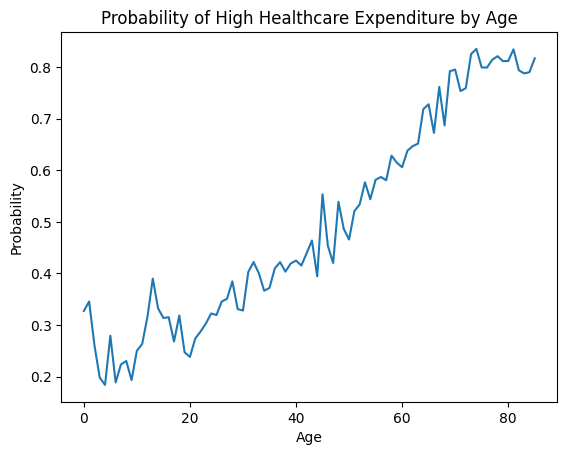

In [50]:
age_chart = df.groupby('AGE22X')['high_exp'].mean()

age_chart.plot()
plt.title("Probability of High Healthcare Expenditure by Age")
plt.xlabel("Age")
plt.ylabel("Probability")
plt.show()


# High Cost Probability by Multimorbidity


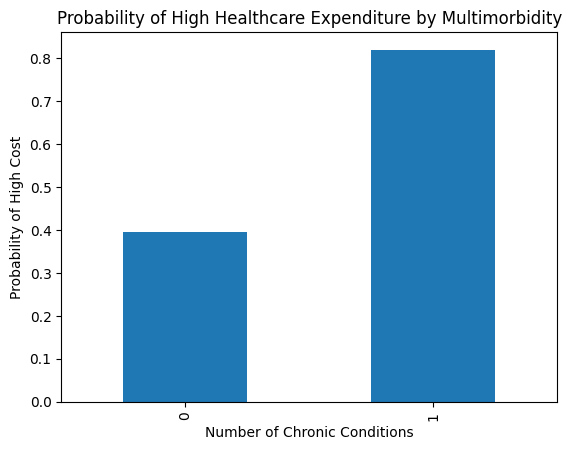

In [51]:
multi_chart = df.groupby('multimorbidity')['high_exp'].mean()

multi_chart.plot(kind='bar')
plt.title("Probability of High Healthcare Expenditure by Multimorbidity")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Probability of High Cost")
plt.show()


# Map Visualization

In [52]:
# ===============================
# MAP VISUALIZATION — Choropleth
# ===============================

import plotly.express as px
import pandas as pd

# Step 1: Compute high expenditure rate per region (filter dirty code first)
region_map = df[df['REGION22'] > 0].groupby('REGION22')['high_exp'].mean().reset_index()

# Step 2: Map MEPS region codes to names and US state abbreviations
# MEPS codes: 1=Northeast, 2=Midwest, 3=South, 4=West
region_info = pd.DataFrame({
    'REGION22'    : [1,        2,         3,       4     ],
    'region_name' : ['Northeast', 'Midwest', 'South', 'West'],
    # Representative states for each region (for choropleth mapping)
    'state_codes' : [
        ['CT','ME','MA','NH','RI','VT','NJ','NY','PA'],           # Northeast
        ['IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD'], # Midwest
        ['DE','FL','GA','MD','NC','SC','VA','WV','AL','KY','MS','TN',
         'AR','LA','OK','TX','DC'],                               # South
        ['AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA'] # West
    ]
})

# Step 3: Merge region rates with region info
region_map = region_map.merge(region_info[['REGION22','region_name','state_codes']], on='REGION22')

# Step 4: Explode — one row per state so plotly can shade by state
region_map_states = region_map.explode('state_codes').rename(columns={'state_codes': 'state'})

# Step 5: Plot choropleth
fig = px.choropleth(
    region_map_states,
    locations='state',
    locationmode='USA-states',
    color='high_exp',
    scope='usa',
    color_continuous_scale='Blues',
    labels={'high_exp': 'High Exp Rate', 'region_name': 'Region'},
    title='High Healthcare Expenditure Rate by US Region (MEPS 2022)',
    hover_name='region_name',
    hover_data={'high_exp': ':.3f', 'state': False}
)

fig.update_layout(
    coloraxis_colorbar=dict(title='Proportion<br>High Spenders'),
    geo=dict(showlakes=True, lakecolor='rgb(255,255,255)')
)

fig.show()

# Step 6: Also print the region-level summary table
print("\nRegion-Level High Expenditure Summary:")
print(region_map[['region_name', 'high_exp']].rename(
    columns={'region_name': 'Region', 'high_exp': 'High Exp Rate'}
).to_string(index=False))


Region-Level High Expenditure Summary:
   Region  High Exp Rate
Northeast       0.552135
  Midwest       0.542686
    South       0.455475
     West       0.502020


# Hypothesis Testing


In [53]:
from scipy.stats import ttest_ind

high = df[df['high_exp']==1]['multimorbidity']
low = df[df['high_exp']==0]['multimorbidity']

t_stat, p_value = ttest_ind(high, low)

print("T statistic:", t_stat)
print("P value:", p_value)

T statistic: 58.2538034701703
P value: 0.0


# Logistic Regression Model


In [54]:
model = smf.logit(
    'high_exp ~ multimorbidity + AGE22X + female + POVCAT22 + EDUCYR',
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.588169
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               high_exp   No. Observations:                20707
Model:                          Logit   Df Residuals:                    20701
Method:                           MLE   Df Model:                            5
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.1506
Time:                        22:03:07   Log-Likelihood:                -12179.
converged:                       True   LL-Null:                       -14339.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.3181      0.063    -36.684      0.000      -2.442      -2.194
multimorbidity   

# Odds Ratios


In [55]:
params = model.params
conf = model.conf_int()

or_table = pd.DataFrame({
    "Odds Ratio": np.exp(params),
    "Lower CI": np.exp(conf[0]),
    "Upper CI": np.exp(conf[1])
})

print(or_table)

                Odds Ratio  Lower CI  Upper CI
Intercept         0.098457  0.086988  0.111439
multimorbidity    3.828988  3.506097  4.181615
AGE22X            1.021484  1.019641  1.023330
female            1.528222  1.437679  1.624466
POVCAT22          1.142567  1.116668  1.169066
EDUCYR            1.033558  1.024976  1.042211


# Relative Risk Table

In [56]:
risk_table = pd.crosstab(df['female'],df['high_exp'])

male_risk = risk_table.loc[0,1]/risk_table.loc[0].sum()
female_risk = risk_table.loc[1,1]/risk_table.loc[1].sum()

RR = female_risk/male_risk

print("Relative Risk (Female vs Male):",RR)

Relative Risk (Female vs Male): 1.2396083240999622


## LASSO Logistic Regression

In [57]:

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay,
                              confusion_matrix)
features = ['multimorbidity', 'AGE22X', 'female', 'POVCAT22', 'EDUCYR']
X = df[features].dropna()
y = df.loc[X.index, 'high_exp']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

lasso = LogisticRegressionCV(
    cv=5, penalty='l1', solver='liblinear',
    random_state=42, max_iter=1000
)
lasso.fit(X_train, y_train)

lasso_coef = pd.DataFrame({
    'Feature'           : features,
    'LASSO Coefficient' : lasso.coef_[0]
})
print("LASSO Coefficients:")
print(lasso_coef.to_string(index=False))
print(f"\nBest C (regularization): {lasso.C_[0]:.4f}")


LASSO Coefficients:
       Feature  LASSO Coefficient
multimorbidity           0.584912
        AGE22X           0.472743
        female           0.199054
      POVCAT22           0.177345
        EDUCYR           0.136568

Best C (regularization): 0.0464


## LASSO Model Performance

In [58]:

y_pred = lasso.predict(X_test)
y_prob = lasso.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.73      0.70      1992
           1       0.73      0.66      0.69      2150

    accuracy                           0.70      4142
   macro avg       0.70      0.70      0.70      4142
weighted avg       0.70      0.70      0.70      4142

AUC-ROC Score: 0.7514



##  CELL 15 – LASSO Coefficient Plot


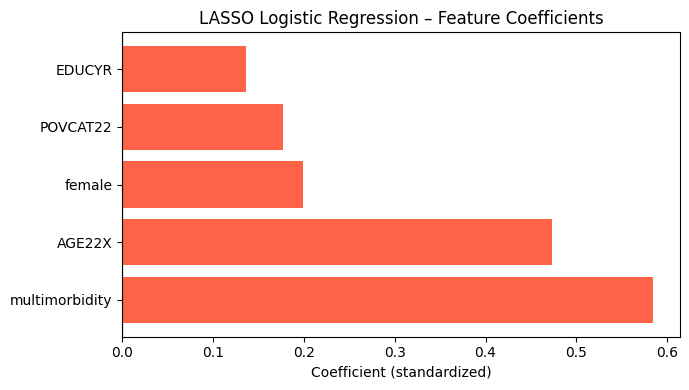

In [59]:

colors = ['tomato' if c > 0 else 'steelblue' for c in lasso_coef['LASSO Coefficient']]
plt.figure(figsize=(7, 4))
plt.barh(lasso_coef['Feature'], lasso_coef['LASSO Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('LASSO Logistic Regression – Feature Coefficients')
plt.xlabel('Coefficient (standardized)')
plt.tight_layout()
plt.show()

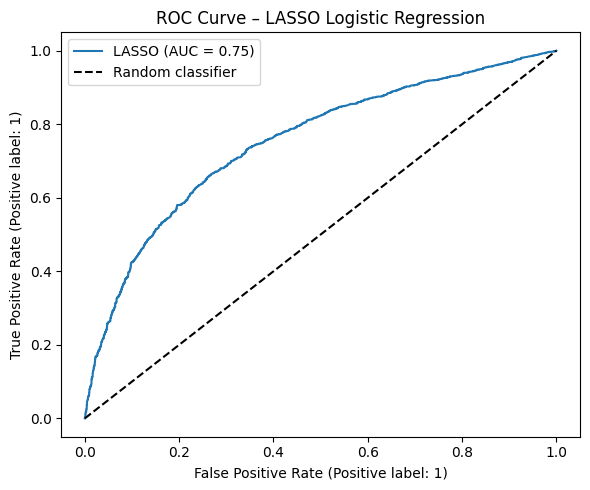

In [60]:

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax, name='LASSO')
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')
ax.set_title('ROC Curve – LASSO Logistic Regression')
ax.legend()
plt.tight_layout()
plt.show()

 ## Confusion Matrix


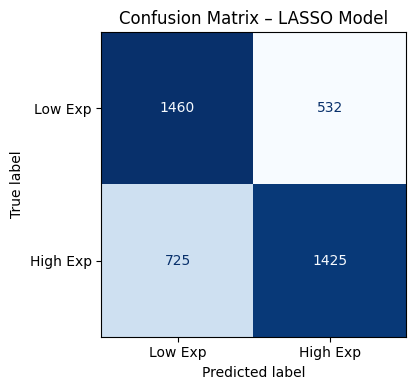

In [61]:

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Exp', 'High Exp'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix – LASSO Model')
plt.tight_layout()
plt.show()